# Homework 7

## Your Name Here (or your names here if you are pair programming)

Student Name: Lily Nguyen

Student UT EID: lmn934

---

Partner Name: John "Jack" Mayberry

Partner UT EID: jmm23398

---

Date Created: Wednesday, July 16th, 2025

Date Last Modified:

---

Total Points 20. 



## Supprt Vector Machine 

In [1]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [2]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 Implement SVM using libraries (4 points)
We want to use **Suppert Vector Machine** to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data, and implement Support Vector Machine using Scikit-Learn. 





In [3]:
# Add your code Here! 

# map target to 1 / 0
heart_df['Target'] = heart_df['Target'].map({'Yes':1,'No':0})

# train/test split the data
shuffled_df = heart_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.8 * len(shuffled_df))

train_set = shuffled_df[:train_size]
test_set = shuffled_df[train_size:]

features = ['Age', 'Sex', 'Chol']
target = ['Target']
num_features = len(features)

# split dataset train/test 80/20
X_train = train_set[features].to_numpy(dtype=float)
X_test = test_set[features].to_numpy(dtype=float)
y_train = train_set[target].to_numpy(dtype=float).ravel()
y_test = test_set[target].to_numpy(dtype=float).ravel()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(f'Train %: {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}')
print(f'Test %: {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}')

(242, 3)
(61, 3)
(242,)
(61,)
Train %: 80%
Test %: 20%


In [4]:
from sklearn import svm
from sklearn.metrics import accuracy_score


model = svm.SVC()
model.fit(X_train, y_train)



y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.5409836065573771


# Task 2 - (4 points)

Cacluate the accuracy, Precision, Recall and F1 score of your **SVM** implementaion from Task 1. 
Print the results. 

You may use library methods for this task if you choose to.


In [5]:
# Add your code Here! 

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print()

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

Accuracy Score: 0.5409836065573771

              precision    recall  f1-score   support

         0.0       0.60      0.69      0.64        36
         1.0       0.42      0.32      0.36        25

    accuracy                           0.54        61
   macro avg       0.51      0.51      0.50        61
weighted avg       0.52      0.54      0.53        61



# Task 3 - Implement SVM without using libraries  - (4 points)

Implement SVM from scratch using Hinge Loss function and Gradient Descent. 
Try to produce the same result as you get from the libraries. 


* Do as many iterations as needed 
* Do maximum **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher. 
* Visualize your costs. 
* No need to add an y-intercept in this task. 
* You can use libraries to report accuracy, Precision, Recall and F1. 



In [6]:
def compute_cost(X, y, W, regularization_factor):
    n = X.shape[0]
    distances = 1 - y * (np.dot(X, W))
    
    distances[distances < 0] = 0 
    
    hinge_loss = regularization_factor * (np.sum(distances) / n)
    return (1 / 2 * np.dot(W, W) + hinge_loss)

In [7]:
def calculate_gradient(X, y, W, regularization_factor):
      
    if type(y) == np.float64:
        y = np.array([y])
        X = np.array([X])
        
    distance = 1 - (y * np.dot(X, W))
    
    dw = np.zeros(len(W))
    
    for ind, d in enumerate(distance):
        
        if (d < 0):
            di = W
        else:
            di = W - (regularization_factor * y[ind] * X[ind])
            
            
        dw += di
    
    dw = dw/len(y)
    
    return dw

In [8]:
weights = np.zeros(3)

num_iterations = 100
learning_rate = 0.01

regularization = 0.01

cost_list = []

for i in range(0, num_iterations):
    
    cost = compute_cost(X_train, y_train, weights, regularization)
    
    print("Epoch", i, "Cost is:", cost, "weights", weights)
    
    cost_list.append(cost)
    
    grad = calculate_gradient(X_train, y_train, weights, regularization)
    
    weights = weights - learning_rate * grad

Epoch 0 Cost is: 0.01 weights [0. 0. 0.]
Epoch 1 Cost is: 0.0053632402506659385 weights [2.64297521e-03 3.88429752e-05 1.18735537e-02]
Epoch 2 Cost is: 0.005361767968024794 weights [2.61654545e-03 3.84545455e-05 1.17548182e-02]
Epoch 3 Cost is: 0.005360324983808208 weights [2.590380e-03 3.807000e-05 1.163727e-02]
Epoch 4 Cost is: 0.005358910714977532 weights [2.56447620e-03 3.76893000e-05 1.15208973e-02]
Epoch 5 Cost is: 0.005357524590096587 weights [2.53883144e-03 3.73124070e-05 1.14056883e-02]
Epoch 6 Cost is: 0.005356166049100772 weights [2.51344312e-03 3.69392829e-05 1.12916314e-02]
Epoch 7 Cost is: 0.005354834543070774 weights [2.48830869e-03 3.65698901e-05 1.11787151e-02]
Epoch 8 Cost is: 0.005353529534010773 weights [2.46342561e-03 3.62041912e-05 1.10669280e-02]
Epoch 9 Cost is: 0.005352250494631066 weights [2.43879135e-03 3.58421493e-05 1.09562587e-02]
Epoch 10 Cost is: 0.005350996908135015 weights [2.41440344e-03 3.54837278e-05 1.08466961e-02]
Epoch 11 Cost is: 0.0053497682680

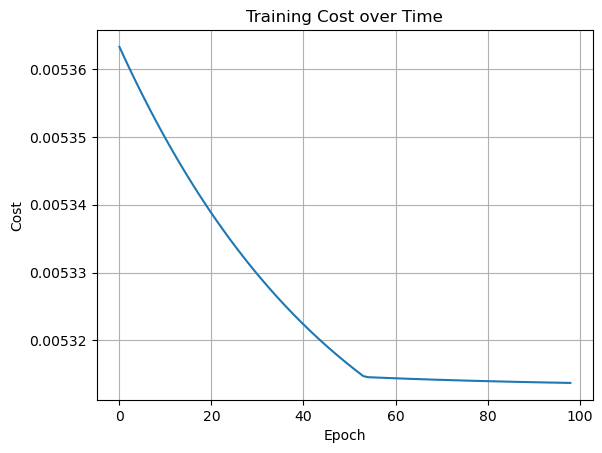

In [9]:
plt.plot(cost_list[1:])
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost over Time")
plt.grid(True)
plt.show()

In [10]:
y_predict_2 = np.where(np.dot(X_test, weights)<0, -1, 1)

def predict_svm(weights, X):
    return np.where(np.dot(X, weights)<0, -1, 1)

print("Accuracy Score:", accuracy_score(y_test, predict_svm(weights, X_test)))

print(classification_report(y_test,predict_svm(weights, X_test)))

Accuracy Score: 0.4098360655737705
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        36
         1.0       0.41      1.00      0.58        25

    accuracy                           0.41        61
   macro avg       0.20      0.50      0.29        61
weighted avg       0.17      0.41      0.24        61



C:\Users\jackm\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackm\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jackm\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task 4 - Compare SVM results with Logistic Regression - (4 points)

Which model performs better here? Compare your results wit the logistic regression. You can use libraries for this task, it is not necessary to implement logistic regression from sratch.


In [11]:
# Add your code Here! 

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("Without Intercept:", accuracy_score(y_test,y_pred))

model = LogisticRegression(fit_intercept=True)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("With Intercept:", accuracy_score(y_test,y_pred))

Without Intercept: 0.7540983606557377
With Intercept: 0.7540983606557377


# Task 5 - Apply a kernel function to improve SVM performance (4 points)

Use the Scikit-learn librariy and apply a kernel function to improve the SVM performance. Check if this is possible. 


In [12]:
# Add your code Here! 